In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [ ]:
climate_df = pd.read_csv("../data/climate_and_population_data.csv")

In [104]:
climate_df.head(12)

,month,high_temp_F,low_temp_F,mean_temp_F,precipitation_in,humidity_percent,dew_point_F,wind_mph,pressure_Hg,visibility_mi,city,country,region,lat,lng,population
0,January,89.0,75.0,82.0,1.57,75.0,73.0,14.0,29.85,5.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
1,February,90.0,77.0,84.0,1.79,77.0,75.0,17.0,29.84,6.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
2,March,91.0,78.0,84.0,2.29,78.0,76.0,17.0,29.83,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
3,April,90.0,78.0,84.0,2.93,78.0,76.0,16.0,29.83,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
4,May,89.0,77.0,83.0,5.11,80.0,75.0,15.0,29.87,8.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
5,June,85.0,75.0,80.0,6.39,84.0,74.0,15.0,29.93,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
6,July,83.0,75.0,79.0,2.78,84.0,73.0,19.0,29.95,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
7,August,83.0,74.0,78.0,1.83,84.0,72.0,20.0,29.95,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
8,September,85.0,75.0,79.0,2.44,84.0,73.0,19.0,29.92,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0
9,October,86.0,75.0,80.0,3.75,83.0,74.0,15.0,29.88,7.0,Accra,Ghana,Greater Accra,5.556,-0.1969,1782150.0


In [105]:
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             1668 non-null   object 
 1   high_temp_F       1668 non-null   float64
 2   low_temp_F        1668 non-null   float64
 3   mean_temp_F       1668 non-null   float64
 4   precipitation_in  1668 non-null   float64
 5   humidity_percent  1668 non-null   float64
 6   dew_point_F       1668 non-null   float64
 7   wind_mph          1668 non-null   float64
 8   pressure_Hg       1668 non-null   float64
 9   visibility_mi     1656 non-null   float64
 10  city              1668 non-null   object 
 11  country           1668 non-null   object 
 12  region            1668 non-null   object 
 13  lat               1668 non-null   float64
 14  lng               1668 non-null   float64
 15  population        1668 non-null   float64
dtypes: float64(12), object(4)
memory usage: 20

In [106]:
climate_df.describe()

,high_temp_F,low_temp_F,mean_temp_F,precipitation_in,humidity_percent,dew_point_F,wind_mph,pressure_Hg,visibility_mi,lat,lng,population
count,1668.000000,1668.000000,1668.000000,1668.000000,1668.000000,1668.000000,1668.000000,1668.000000,1656.000000,1668.000000,1668.000000,1.668000e+03
mean,71.797962,54.628297,63.207434,3.018195,69.060552,51.004197,13.089329,29.963657,8.119565,24.700135,3.161191,5.912364e+06
std,18.082111,17.295858,17.505064,2.785105,12.958632,16.470092,4.576202,0.138248,3.975934,27.014075,81.609157,7.318287e+06
min,-1.000000,-15.000000,-8.000000,0.000000,10.000000,-12.000000,2.000000,29.440000,1.000000,-37.814200,-157.846000,1.322400e+04
25%,61.000000,43.000000,52.000000,1.287500,64.000000,40.000000,10.000000,29.890000,6.000000,12.979100,-75.133900,1.249597e+06
50%,76.000000,56.000000,66.000000,2.360000,71.000000,52.000000,13.000000,29.980000,7.000000,32.793500,12.568900,2.748109e+06
75%,86.000000,69.000000,77.000000,3.852500,78.000000,64.000000,16.000000,30.050000,10.000000,44.647500,55.309400,7.171000e+06
max,116.000000,89.000000,101.000000,33.050000,90.000000,79.000000,30.000000,30.410000,32.000000,64.733300,178.433300,3.910500e+07


In the dataset we have 1668 rows each row represents weahter information for a city in a particual month. The stucture of each row is:
City -> Month -> Weather Characteristics plus Population.

In [107]:
print(f"Number of unique cities: {climate_df['city'].nunique()}")

Number of unique cities: 139


In [108]:
print(f"Number of unique countries: {climate_df['country'].nunique()}")

Number of unique countries: 91


In [109]:
print(f"Number of unique regions: {climate_df['region'].nunique()}")

Number of unique regions: 134


In [110]:
# How many observations are there for each country
climate_df["country"].value_counts()

country
United States           264
Canada                  108
Australia                84
India                    48
Pakistan                 36
                       ... 
Croatia                  12
United Arab Emirates     12
Switzerland              12
Ireland                  12
Kenya                    12
Name: count, Length: 91, dtype: int64

In [111]:
# Hot cities with the highest average temperature
climate_df.sort_values(by="high_temp_F", ascending=False).head(10)

,month,high_temp_F,low_temp_F,mean_temp_F,precipitation_in,humidity_percent,dew_point_F,wind_mph,pressure_Hg,visibility_mi,city,country,region,lat,lng,population
870,July,116.0,87.0,101.0,2.61,14.0,43.0,21.0,29.48,5.0,Kuwait City,Kuwait,Al Asimah,29.3750,47.9800,2989000.0
871,August,116.0,86.0,101.0,1.60,18.0,47.0,18.0,29.53,5.0,Kuwait City,Kuwait,Al Asimah,29.3750,47.9800,2989000.0
869,June,113.0,84.0,98.0,3.51,13.0,39.0,22.0,29.58,5.0,Kuwait City,Kuwait,Al Asimah,29.3750,47.9800,2989000.0
498,July,111.0,86.0,98.0,1.20,10.0,33.0,15.0,29.51,6.0,Riyadh,Saudi Arabia,Ar Riyad,24.6500,46.7100,7237000.0
499,August,110.0,85.0,98.0,1.29,12.0,36.0,13.0,29.56,6.0,Riyadh,Saudi Arabia,Ar Riyad,24.6500,46.7100,7237000.0
497,June,109.0,84.0,96.0,1.10,10.0,31.0,15.0,29.61,6.0,Riyadh,Saudi Arabia,Ar Riyad,24.6500,46.7100,7237000.0
872,September,109.0,79.0,94.0,0.63,21.0,46.0,16.0,29.70,6.0,Kuwait City,Kuwait,Al Asimah,29.3750,47.9800,2989000.0
1577,June,108.0,87.0,97.0,0.01,36.0,62.0,18.0,29.54,6.0,Doha,Qatar,Ad Dawhah,25.2861,51.5294,1186023.0
1578,July,108.0,89.0,99.0,0.11,44.0,69.0,16.0,29.46,6.0,Doha,Qatar,Ad Dawhah,25.2861,51.5294,1186023.0
1579,August,107.0,89.0,98.0,0.00,57.0,77.0,14.0,29.52,6.0,Doha,Qatar,Ad Dawhah,25.2861,51.5294,1186023.0


In [112]:
# Cold cities with the lowest average temperature
climate_df.sort_values(by="low_temp_F", ascending=True).head(10)

,month,high_temp_F,low_temp_F,mean_temp_F,precipitation_in,humidity_percent,dew_point_F,wind_mph,pressure_Hg,visibility_mi,city,country,region,lat,lng,population
252,January,-1.0,-15.0,-8.0,1.61,81.0,-12.0,26.0,29.99,13.0,Anadyr,Russia,Chukotskiy Avtonomnyy Okrug,64.7333,177.5042,13224.0
253,February,1.0,-13.0,-6.0,1.84,81.0,-10.0,28.0,29.95,12.0,Anadyr,Russia,Chukotskiy Avtonomnyy Okrug,64.7333,177.5042,13224.0
263,December,4.0,-10.0,-3.0,1.38,82.0,-7.0,29.0,29.90,12.0,Anadyr,Russia,Chukotskiy Avtonomnyy Okrug,64.7333,177.5042,13224.0
254,March,6.0,-8.0,-1.0,1.46,81.0,-5.0,26.0,30.03,14.0,Anadyr,Russia,Chukotskiy Avtonomnyy Okrug,64.7333,177.5042,13224.0
1525,February,16.0,0.0,8.0,0.45,71.0,1.0,8.0,30.12,NaN,Winnipeg,Canada,Manitoba,49.8844,-97.1464,758515.0
12,January,21.0,1.0,11.0,0.82,74.0,5.0,14.0,30.07,13.0,Edmonton,Canada,Alberta,53.5344,-113.4903,1151635.0
23,December,23.0,2.0,13.0,0.63,75.0,7.0,14.0,30.03,13.0,Edmonton,Canada,Alberta,53.5344,-113.4903,1151635.0
1524,January,16.0,2.0,9.0,0.70,75.0,2.0,9.0,30.07,NaN,Winnipeg,Canada,Manitoba,49.8844,-97.1464,758515.0
13,February,24.0,2.0,13.0,0.53,73.0,7.0,14.0,30.08,13.0,Edmonton,Canada,Alberta,53.5344,-113.4903,1151635.0
255,April,18.0,4.0,11.0,0.93,82.0,7.0,22.0,30.00,15.0,Anadyr,Russia,Chukotskiy Avtonomnyy Okrug,64.7333,177.5042,13224.0


In [113]:
# Where do hot and humid conditions occur together?
climate_df[(climate_df["high_temp_F"] > 90) & (climate_df["humidity_percent"] > 70)].sort_values(by="high_temp_F", ascending=False).head(10)

,month,high_temp_F,low_temp_F,mean_temp_F,precipitation_in,humidity_percent,dew_point_F,wind_mph,pressure_Hg,visibility_mi,city,country,region,lat,lng,population
66,July,98.0,81.0,89.0,8.82,74.0,79.0,8.0,29.47,1.0,New Delhi,India,Delhi,28.6139,77.2089,249998.0
1564,May,97.0,76.0,86.0,5.90,74.0,76.0,10.0,29.75,4.0,Rangoon,Burma,Yangon,16.8053,96.1561,5160512.0
796,May,97.0,78.0,88.0,5.70,74.0,77.0,11.0,29.63,2.0,Kolkata,India,West Bengal,22.5675,88.3700,21747000.0
543,April,97.0,80.0,88.0,4.67,71.0,76.0,13.0,29.79,6.0,Bangkok,Thailand,Krung Thep Maha Nakhon,13.7500,100.5167,18007000.0
544,May,95.0,80.0,88.0,7.99,73.0,76.0,12.0,29.75,6.0,Bangkok,Thailand,Krung Thep Maha Nakhon,13.7500,100.5167,18007000.0
67,August,95.0,80.0,88.0,10.06,76.0,78.0,8.0,29.54,1.0,New Delhi,India,Delhi,28.6139,77.2089,249998.0
161,June,94.0,80.0,87.0,7.71,74.0,77.0,12.0,29.62,5.0,Hanoi,Vietnam,Ha Noi,21.0245,105.8412,4138510.0
797,June,94.0,80.0,87.0,9.30,80.0,79.0,9.0,29.53,2.0,Kolkata,India,West Bengal,22.5675,88.3700,21747000.0
545,June,94.0,79.0,86.0,8.28,74.0,76.0,13.0,29.73,6.0,Bangkok,Thailand,Krung Thep Maha Nakhon,13.7500,100.5167,18007000.0
1015,August,94.0,80.0,87.0,8.07,74.0,77.0,9.0,29.55,3.0,Lahore,Pakistan,Punjab,31.5497,74.3436,13004135.0


In [114]:
# Fill missing visibility data with the mean of the specific city's visibility data
missing_cities = climate_df[climate_df['visibility_mi'].isna()]['city'].unique()
print(missing_cities)

['Winnipeg']


In [115]:
# Fill missing visibility data with the mean of the specific country visibility data
climate_df['visibility_mi'] = climate_df.groupby('country')['visibility_mi'].transform(lambda x: x.fillna(x.mean()))

In [116]:
# Check for any remaining missing values in the dataset
climate_df.isnull().sum()

month               0
high_temp_F         0
low_temp_F          0
mean_temp_F         0
precipitation_in    0
humidity_percent    0
dew_point_F         0
wind_mph            0
pressure_Hg         0
visibility_mi       0
city                0
country             0
region              0
lat                 0
lng                 0
population          0
dtype: int64

In [117]:
# Convert the month column to a categorical type for better visualization
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
climate_df['month'] = pd.Categorical(climate_df['month'], categories=months, ordered=True)

## Distribution of the mean temperatures

<Axes: xlabel='mean_temp_F', ylabel='Count'>

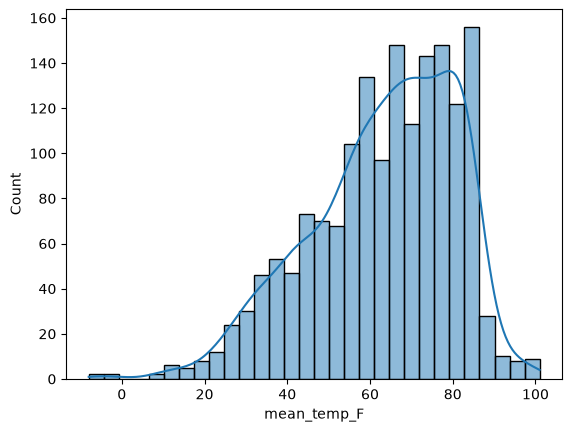

In [118]:
sns.histplot(data=climate_df, x="mean_temp_F", bins=30, kde=True)

## Distribution of the precipitation_in

<Axes: xlabel='precipitation_in', ylabel='Count'>

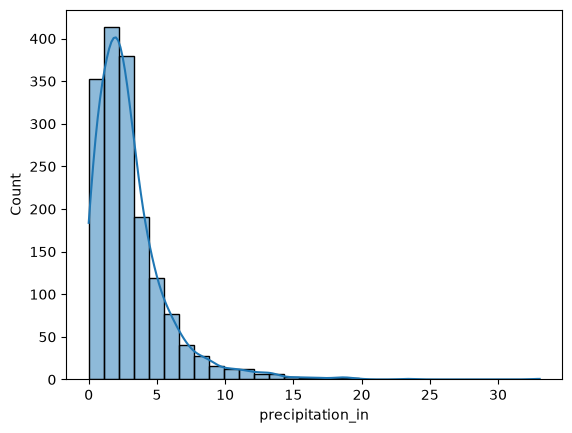

In [119]:
sns.histplot(data=climate_df, x="precipitation_in", bins=30, kde=True)

Precipitation is skewed to the right, though majority of the cities have percipitation in the range of 0 and 5.

## Distribution of the wind_mph

<Axes: xlabel='wind_mph', ylabel='Count'>

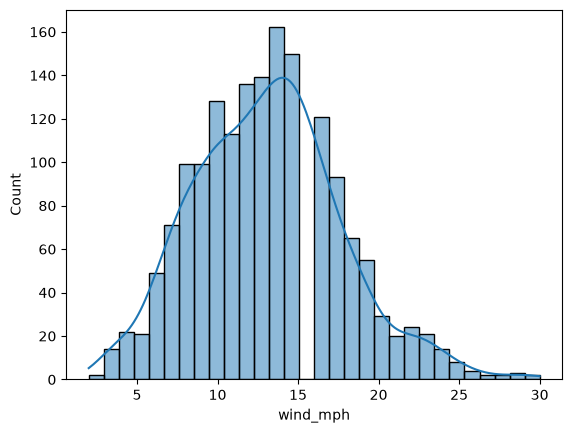

In [120]:
sns.histplot(data=climate_df, x="wind_mph", bins=30, kde=True)

## Distribution of the population

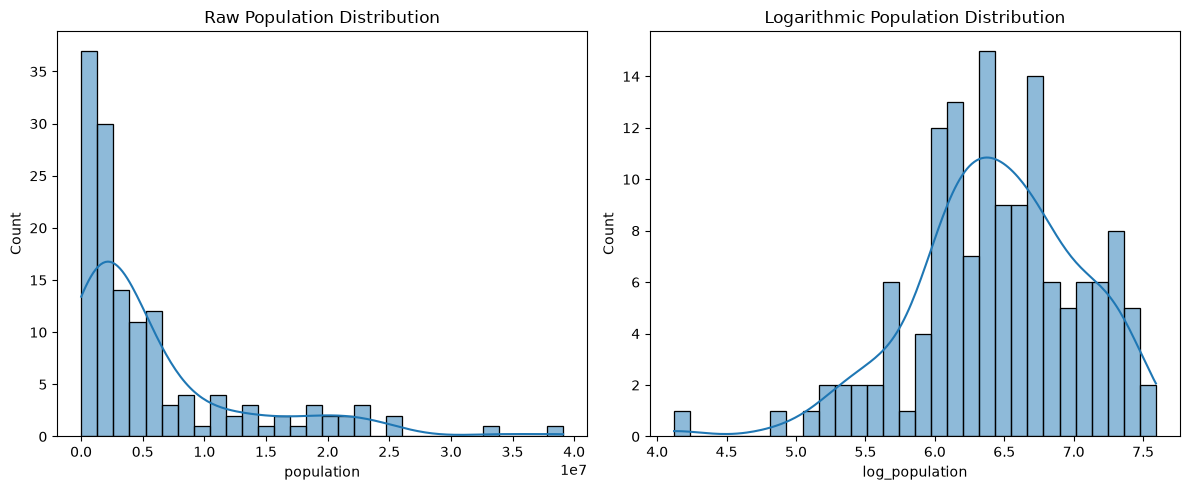

In [121]:
import numpy as np

unique_cities = climate_df.drop_duplicates(subset=["city"]).copy()
unique_cities["log_population"] = np.log10(unique_cities["population"])

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot raw population on the left subplot (axes[0])
sns.histplot(data=unique_cities, x="population", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Raw Population Distribution")

# Plot log population on the right subplot (axes[1])
sns.histplot(data=unique_cities, x="log_population", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Logarithmic Population Distribution")

# Adjust spacing to prevent labels from overlapping
plt.tight_layout()
plt.show()

## Geographical Climate Trends

In [122]:
# Scatter plot of Temperature vs. Latitude
fig = px.scatter(
    climate_df,
    x="lat",
    y="mean_temp_F",
    color="region",
    hover_name="city",
    hover_data={"region": True, "lat": True, "mean_temp_F": True},
    title="Mean Temperature vs. Latitude by Region",
    opacity=0.7
)

fig.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="Equator")
fig.update_layout(showlegend=False)
fig.show()

Mean temperature drops as we move away from the equator.

<Axes: xlabel='lat', ylabel='mean_temp_F'>

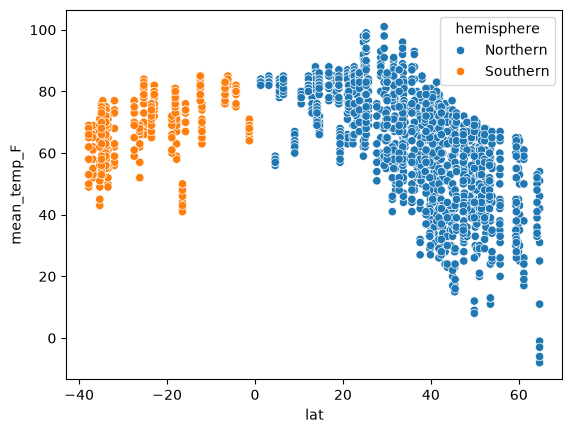

In [123]:
climate_df["hemisphere"] = climate_df["lat"].apply(lambda x: "Northern" if x > 0 else "Southern")

# Compare mean temperature between Northern and Southern Hemispheres
sns.scatterplot(data=climate_df, x="lat", y="mean_temp_F", hue="hemisphere")

The plot indicates that overall mean temperature in the Southern Hemisphere is higher than in the Northern Hemishpere. Furthermore, temperature in the Northern Hemisphere exibit a much sharper decline as distance from the equartor increases.

## Identify most Climate "stable" cities 

In [124]:
climate_stability = climate_df.groupby("city").agg({
    "mean_temp_F": "std",
    "population": "first",
    "country": "first"
}).reset_index()
climate_stability.rename(columns={"mean_temp_F": "temp_std_dev"}, inplace=True)

most_stable_cities = climate_stability.sort_values(by="temp_std_dev").head(10)
display(most_stable_cities)

,city,temp_std_dev,population,country
119,Singapore,0.717741,5453566.0,Singapore
22,Bogota,0.792961,7968095.0,Colombia
69,Kuala Lumpur,0.792961,8430775.0,Malaysia
61,Jakarta,1.164500,33756000.0,Indonesia
112,San Salvador,1.311372,1538525.0,El Salvador
34,Caracas,1.378954,2245744.0,Venezuela
81,Managua,1.505042,1051236.0,Nicaragua
49,Guatemala City,1.906925,994938.0,Guatemala
114,Santo Domingo,1.912875,1029110.0,Dominican Republic
66,Kingston,1.992410,1190000.0,Jamaica


## Population vs Extreme Weather

In [125]:
# Find the average yearly conditions for each city
city_yearly = climate_df.groupby("city").agg({
    "mean_temp_F": "mean",
    "precipitation_in": "sum",
    "population": "first",
    "country": "first",
    "lat": "first",
    "lng": "first"
}).reset_index()

# Which cities over 5 million people get the most precipitation?
megacities = city_yearly[city_yearly["population"] > 5000000]
wettest_megacities = megacities.sort_values(by="precipitation_in", ascending=False).head(10)
display(wettest_megacities)

,city,mean_temp_F,precipitation_in,population,country,lat,lng
69,Kuala Lumpur,83.416667,111.17,8430775.0,Malaysia,3.1478,101.6953
82,Manila,82.333333,105.02,13484482.0,Philippines,14.5958,120.9772
119,Singapore,83.166667,91.95,5453566.0,Singapore,1.3000,103.8000
91,Mumbai,81.666667,89.85,24973000.0,India,19.0758,72.8775
43,Dhaka,80.333333,75.99,19134000.0,Bangladesh,23.7289,90.3944
104,Rangoon,82.083333,73.44,5160512.0,Burma,16.8053,96.1561
85,Miami,77.666667,66.93,6391670.0,United States,25.7840,-80.2101
61,Jakarta,84.083333,63.70,33756000.0,Indonesia,-6.1753,106.8269
68,Kolkata,80.666667,63.41,21747000.0,India,22.5675,88.3700
16,Bangkok,85.000000,62.92,18007000.0,Thailand,13.7500,100.5167


In [126]:
fig = px.scatter_geo(
    wettest_megacities,
    lat='lat',
    lon='lng',               # Plotly expects 'lon', so we pass 'lng' column to it
    size='precipitation_in', # Bubble size is determined by total precipitation
    hover_name='city',       # Shows the city name when hover over the bubble
    projection="natural earth", # Gives the map a rounded, global appearance
    title="Global Distribution of Top Rainiest Cities",
    size_max=30,             # Adjusts how large the biggest bubble can get
    color='precipitation_in',# Optional: adds a color gradient to reinforce the size difference
    color_continuous_scale=px.colors.sequential.Blues # Uses a blue color scale for rain
)

# Display the interactive map
fig.show()

## Coldest average cities

In [127]:
coldest_cities = (climate_df
    .groupby("city")
    .agg({"mean_temp_F": "mean", "population": "first", "country": "first"})
    .sort_values("mean_temp_F")
    .head(10))

display(coldest_cities)

,mean_temp_F,population,country
city,,,
Anadyr,21.083333,13224.0,Russia
Edmonton,36.750000,1151635.0,Canada
Anchorage,38.416667,288976.0,United States
Winnipeg,40.416667,758515.0,Canada
Calgary,40.500000,1306784.0,Canada
Reykjavik,41.500000,239733.0,Iceland
St. John's,41.750000,185565.0,Canada
Helsinki,42.916667,1360075.0,Finland
Ottawa,43.916667,1068821.0,Canada


is there correlation between average temperature and population size?

In [128]:
# Does populatio relate to temperature? Let's visualize the relationship between population and mean temperature.
climate_df[["population", "mean_temp_F"]].corr()

,population,mean_temp_F
population,1.000000,0.198109
mean_temp_F,0.198109,1.000000


As we can see there is week corrleation between population and mean temperature, which suggests that higher temperature itself doesn't lead to the higher population. Temperature only dictates population at the extreme fringes. Most likely population is affected by the economic factors, hystorical age of the settlement and geographic features rather than weather metrics.

## Feature Correlation (What drives the weather)

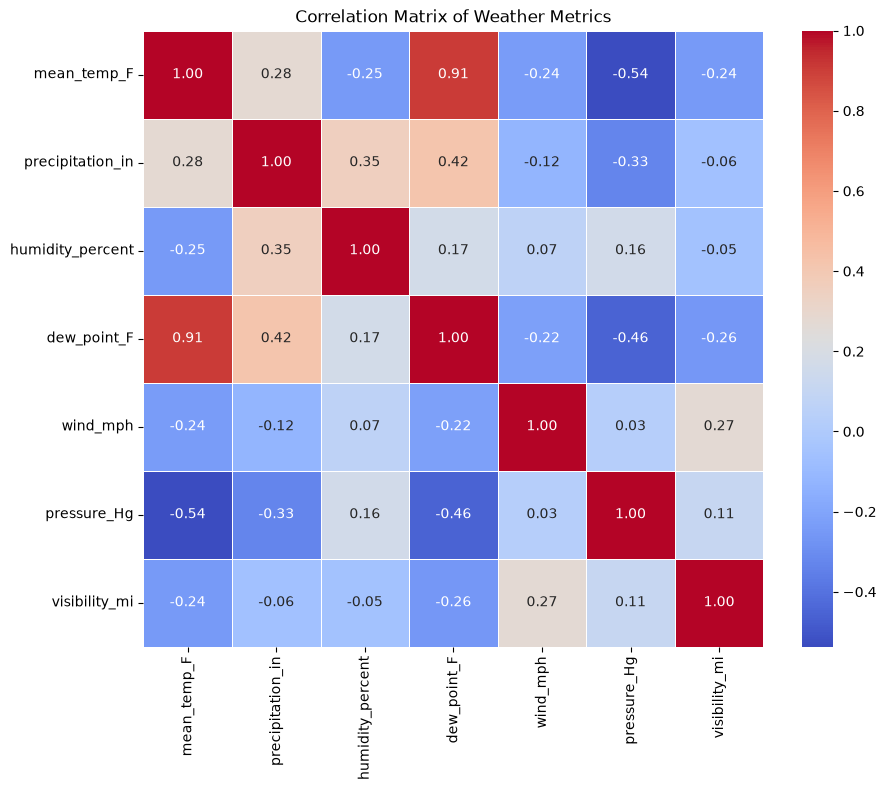

In [129]:
weather_metrics = climate_df[['mean_temp_F', 'precipitation_in', 'humidity_percent', 
                              'dew_point_F', 'wind_mph', 'pressure_Hg', 'visibility_mi']]

# Calculate the correlation matrix for the weather metrics
correlation_matrix = weather_metrics.corr()

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Weather Metrics")
plt.show()